In [1]:
import json
import numpy as np
from pathlib import Path
import zipfile
from typing import Dict, List
import matplotlib.pyplot as plt

Loading Matrices and Estimating Input Length

In [25]:
def load_attention_matrices_from_zip(zip_path: str) -> List[np.ndarray]:
    matrices = []

    # Determine parsing logic based on the zip_path itself
    parse_mode = 'default'
    if 'cad_attn.zip' in zip_path or 'kg_attention.zip' in zip_path or 'attention_matrices.zip' in zip_path:
        parse_mode = 'mean_attention_final_step'
    elif 'ama_attn.zip' in zip_path:
        parse_mode = 'final_token_attn'
    elif 'rag_attn.zip' in zip_path:
        parse_mode = 'rag_attn_1d_as_row'

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        for filename in zip_ref.namelist():
            if filename.endswith('.json'):
                with zip_ref.open(filename) as f:
                    try:
                        data = json.load(f)
                        attn_matrix = None

                        if parse_mode == 'mean_attention_final_step':
                            if isinstance(data, dict) and 'mean_attention_final_step' in data and data['mean_attention_final_step']:
                                attn_matrix_data = data['mean_attention_final_step'][0]
                                if isinstance(attn_matrix_data, str):
                                    attn_matrix_data = json.loads(attn_matrix_data)
                                attn_matrix = np.array(attn_matrix_data)
                        elif parse_mode == 'final_token_attn':
                            if isinstance(data, dict) and 'final_token_attn' in data and data['final_token_attn']:
                                attn_matrix_data = data['final_token_attn'][0]
                                if isinstance(attn_matrix_data, str):
                                    attn_matrix_data = json.loads(attn_matrix_data)
                                attn_matrix = np.array(attn_matrix_data)
                        elif parse_mode == 'rag_attn_1d_as_row':
                            # For rag_attn.zip, assume the JSON content is a 1D array
                            # and treat it as a single row of a 2D matrix.
                            if isinstance(data, list):
                                attn_matrix = np.array(data).reshape(1, -1)
                        else: # default mode, assume the whole data is the matrix
                            # Attempt to create a numpy array from data
                            temp_matrix = np.array(data)
                            # Only use if it's a 2D array or higher (to be iterable as rows)
                            if temp_matrix.ndim >= 2:
                                attn_matrix = temp_matrix
                            else:
                                # print(f"Warning: Skipping {filename} in {zip_path}. Expected a 2D matrix, but direct load resulted in {temp_matrix.ndim}-D array (shape: {temp_matrix.shape}).")
                                pass # Suppress warning to avoid too much output

                        # Final check to ensure it's a 2D matrix before appending
                        if attn_matrix is not None and attn_matrix.ndim >= 2:
                            matrices.append(attn_matrix)
                        elif attn_matrix is not None:
                            # print(f"Warning: Skipping {filename} in {zip_path}. Resulting matrix is not 2D. Shape: {attn_matrix.shape}")
                            pass # Suppress warning to avoid too much output

                    except json.JSONDecodeError:
                        # print(f"Error: Skipping {filename} in {zip_path} due to JSON decoding error.")
                        pass # Suppress error to avoid too much output
                    except KeyError as e:
                        # print(f"Error: Skipping {filename} in {zip_path} due to missing key: {e}.")
                        pass # Suppress error to avoid too much output
                    except Exception as e:
                        # print(f"Error: Skipping {filename} in {zip_path} due to unexpected error: {e}")
                        pass # Suppress error to avoid too much output

    return matrices

def estimate_input_length(matrix: np.ndarray) -> int:
    seq_len = len(matrix)

    causal_scores = []
    for i in range(max(10, int(seq_len * 0.2)), min(seq_len - 10, int(seq_len * 0.8))):
        attn_to_past = matrix[i, :i].sum()
        attn_to_future = matrix[i, i+1:].sum()

        if attn_to_past + attn_to_future > 0:
            causal_ratio = attn_to_past / (attn_to_past + attn_to_future)
            causal_scores.append((i, causal_ratio))

    for i, ratio in causal_scores:
        if ratio > 0.8:
            return i

    attention_spreads = []
    for i in range(seq_len):
        spread = np.std(matrix[i])
        attention_spreads.append(spread)

    if len(attention_spreads) > 20:
        window = 10
        for i in range(window, len(attention_spreads) - window):
            before = np.mean(attention_spreads[max(0, i-window):i])
            after = np.mean(attention_spreads[i:min(len(attention_spreads), i+window)])
            if before > after * 1.5:  # Significant drop
                return i

    return int(seq_len * 0.45)

Computing Metrix: Entropy, Concentration

In [21]:
def compute_attention_entropy(matrix: np.ndarray) -> float:
    """
    Lower entropy = more focused attention = less hallucination.

    Entropy measures how uniform the attention distribution is.
    """
    entropies = []

    for row in matrix:
        # Compute Shannon entropy for this row
        # Filter out zeros to avoid log(0)
        probs = row[row > 0]
        if len(probs) > 0:
            entropy = -np.sum(probs * np.log2(probs))
            entropies.append(entropy)

    return np.mean(entropies)

def compute_attention_concentration(matrix: np.ndarray) -> float:
    """
    Higher concentration = attention focused on fewer tokens = less hallucination.

    Measures the average maximum attention weight per position.
    """
    max_weights = np.max(matrix, axis=1)
    return np.mean(max_weights)

Analyzing Hallucination Mitigation Strategies


Analyzing baseline...
  Loaded 338 attention matrices
  Valid CGS scores: 0/338

Analyzing cad_attn...
  Loaded 289 attention matrices
  Valid CGS scores: 0/289

Analyzing kg_attention...
  Loaded 338 attention matrices
  Valid CGS scores: 0/338

Analyzing rag_attn...
  Loaded 338 attention matrices
  Valid CGS scores: 0/338

Analyzing ama_attn...
  Loaded 338 attention matrices
  Valid CGS scores: 0/338

Visualization saved as 'attention_analysis_results.png'


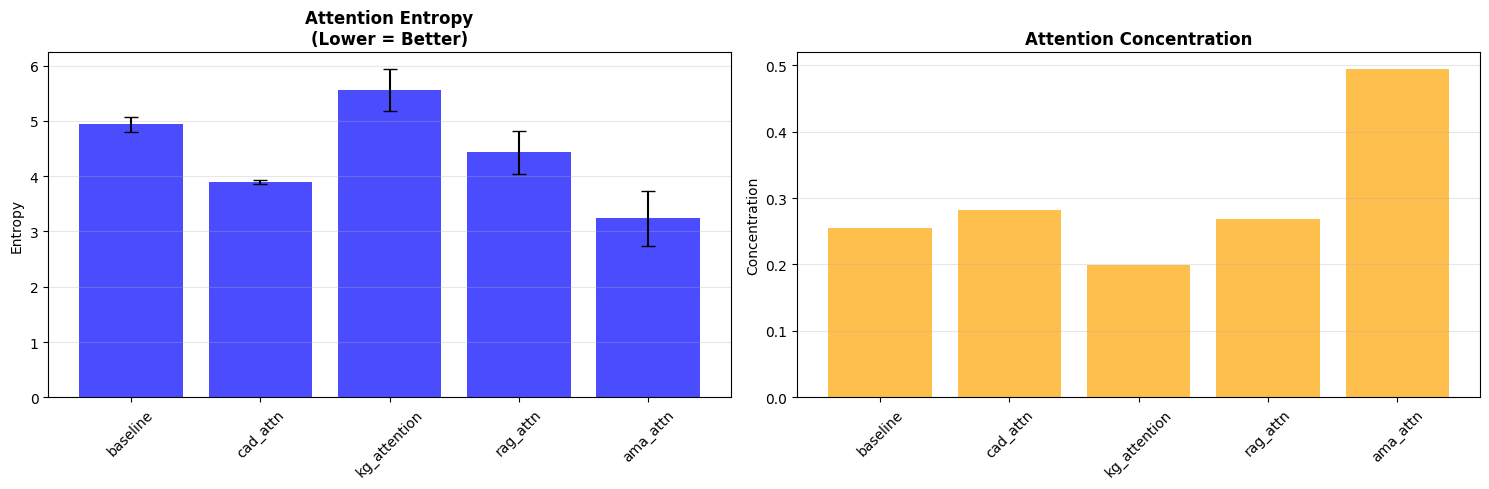


RECOMMENDATION

Best by Context Grounding: baseline
Best by Attention Focus: ama_attn

→ Consider: baseline for better context grounding
→ Consider: ama_attn for more focused attention


In [26]:
def analyze_strategy(zip_path: str, strategy_name: str) -> Dict:
    """Analyze all matrices for one strategy."""
    print(f"\nAnalyzing {strategy_name}...")

    matrices = load_attention_matrices_from_zip(zip_path)
    print(f"  Loaded {len(matrices)} attention matrices")

    cgs_scores = []
    entropy_scores = []
    concentration_scores = []

    for i, matrix in enumerate(matrices):
        #cgs = compute_context_grounding_score(matrix)
        entropy = compute_attention_entropy(matrix)
        concentration = compute_attention_concentration(matrix)

        # Filter out invalid scores
        #if not np.isnan(cgs) and not np.isinf(cgs) and cgs > 0:
        #    cgs_scores.append(cgs)

        if not np.isnan(entropy) and not np.isinf(entropy):
            entropy_scores.append(entropy)

        if not np.isnan(concentration) and not np.isinf(concentration):
            concentration_scores.append(concentration)

    print(f"  Valid CGS scores: {len(cgs_scores)}/{len(matrices)}")

    results = {
        'strategy': strategy_name,
        'num_matrices': len(matrices),
        'cgs_mean': np.mean(cgs_scores) if len(cgs_scores) > 0 else 0.0,
        'cgs_std': np.std(cgs_scores) if len(cgs_scores) > 0 else 0.0,
        'entropy_mean': np.mean(entropy_scores) if len(entropy_scores) > 0 else 0.0,
        'entropy_std': np.std(entropy_scores) if len(entropy_scores) > 0 else 0.0,
        'concentration_mean': np.mean(concentration_scores) if len(concentration_scores) > 0 else 0.0,
        'concentration_std': np.std(concentration_scores) if len(concentration_scores) > 0 else 0.0,
        'cgs_scores': cgs_scores,
        'entropy_scores': entropy_scores,
        'concentration_scores': concentration_scores
    }

    return results

def plot_results(all_results: List[Dict]):
    """Create visualization of results."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    strategies = [r['strategy'] for r in all_results]
    #cgs_means = [r['cgs_mean'] for r in all_results]
    #cgs_stds = [r['cgs_std'] for r in all_results]
    entropy_means = [r['entropy_mean'] for r in all_results]
    entropy_stds = [r['entropy_std'] for r in all_results]
    concentration_means = [r['concentration_mean'] for r in all_results]

    '''
    # CGS comparison
    axes[0].bar(strategies, cgs_means, yerr=cgs_stds, capsize=5, color='green', alpha=0.7)
    axes[0].set_title('Context Grounding Score\n(Higher = Better)', fontweight='bold')
    axes[0].set_ylabel('CGS')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', alpha=0.3)
    '''

    # Entropy comparison
    axes[0].bar(strategies, entropy_means, yerr=entropy_stds, capsize=5, color='blue', alpha=0.7)
    axes[0].set_title('Attention Entropy\n(Lower = Better)', fontweight='bold')
    axes[0].set_ylabel('Entropy')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', alpha=0.3)

    # Concentration comparison
    axes[1].bar(strategies, concentration_means, color='orange', alpha=0.7)
    axes[1].set_title('Attention Concentration', fontweight='bold')
    axes[1].set_ylabel('Concentration')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('attention_analysis_results.png', dpi=300, bbox_inches='tight')
    print("\nVisualization saved as 'attention_analysis_results.png'")
    plt.show()

def main():
    """Main analysis function."""

    # Define your zip file paths
    strategies = {
        'baseline': 'attention_matrices.zip',
        'cad_attn': 'cad_attn.zip',
        'kg_attention': 'kg_attention.zip',
        'rag_attn': 'rag_attn.zip',
        'ama_attn': 'ama_attn.zip',
    }

    # Analyze each strategy
    all_results = []
    for name, zip_path in strategies.items():
        results = analyze_strategy(zip_path, name)
        all_results.append(results)

    # Plot results
    plot_results(all_results)

    # Determine best strategy
    print("\n" + "="*80)
    print("RECOMMENDATION")
    print("="*80)

    best_cgs = max(all_results, key=lambda x: x['cgs_mean'])
    best_entropy = min(all_results, key=lambda x: x['entropy_mean'])

    print(f"\nBest by Context Grounding: {best_cgs['strategy']}")
    print(f"Best by Attention Focus: {best_entropy['strategy']}")

    if best_cgs['strategy'] == best_entropy['strategy']:
        print(f"\n✓ WINNER: {best_cgs['strategy']} performs best on both metrics!")
    else:
        print(f"\n→ Consider: {best_cgs['strategy']} for better context grounding")
        print(f"→ Consider: {best_entropy['strategy']} for more focused attention")

if __name__ == "__main__":
    main()